# Library imports

In [8]:
# Multiprocessing specific : 
from multiprocessing import Pool
import os
from functools import partial
from tqdm.notebook import tqdm

# Regular libraries : 
import pandas as pd
import numpy as np
from math import radians,atan2,sin,cos,acos,asin,pi,acos,sqrt,ceil,atan
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import timeit

# HurrSim library tools
from hurrSim.post_processing import approaching_hurr2MP
from hurrSim import post_processing

#
from scipy.optimize import minimize,fsolve
from scipy.stats import weibull_min
from scipy import stats
import statsmodels.api as sm

# Check if coordinate is land ?
import shapely.geometry as sgeom
import cartopy.io.shapereader as shpreader
from shapely.ops import unary_union
from shapely.prepared import prep

## Importing coordinates of interest

In [9]:
# Setting the grid system : 
# Longitude :
min_lat = 10 # degree
max_lat = 60 # degree
lat_grids = 5 # degree

# Latitude : 
min_long = 0 # degree
max_long = 110 # degree
long_grids = 5 # degree

# Grid info
grid_width = max_long-min_long
grid_height = max_lat-min_lat
nb_width_cell = int(grid_width/long_grids)
nb_height_cell = int(grid_height/lat_grids)
nb_cells = int((nb_width_cell)*(nb_height_cell))

long_range = np.linspace(min_long,max_long,int(nb_width_cell+1))
lat_range = np.linspace(min_lat,max_lat,int(nb_height_cell+1))

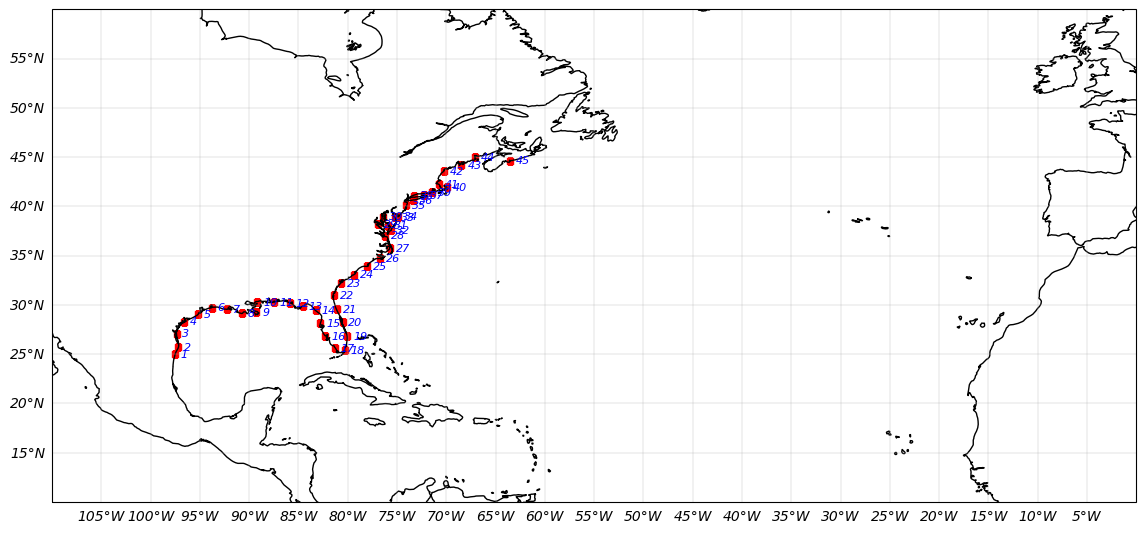

In [10]:
# Dataframe of all coordinates of interest : 
mileposts = pd.read_excel('mileposts.xlsx')

# Limits to which searching for coordinates is not required :  
search_boundaries = (mileposts['Lat'].max()+3,mileposts['Lat'].min()-3,mileposts['Long'].min()-3,mileposts['Long'].max()+3)

# List their individual ids : 
mileposts_ids = mileposts.index.to_list()
milepost_list = [f"Milepost pts {x+1}"for x in mileposts_ids]

# Bit of a visual background information on the mileposts: 
fig_width = 16
fig_height = (4/10)*fig_width
fig = plt.figure(figsize=(fig_width,fig_height))
ax = plt.axes(projection=ccrs.PlateCarree()) 
ax.set_extent([-max_long, min_long, min_lat, max_lat], crs = ccrs.PlateCarree()) 
ax.scatter(mileposts['Long'], mileposts['Lat'], color='red', s=25, marker = 's')
gl = ax.gridlines(xlocs = -long_range, ylocs = lat_range, draw_labels=True,linewidth=0.25)
for row in mileposts.iterrows() : 
    ax.text(row[1]['Long']+0.6, row[1]['Lat']-0.3,f"{row[0]+1}",transform=ccrs.PlateCarree(),size = 8, color = 'b')

gl.top_labels = False
gl.right_labels = False
ax.coastlines()

## Post-processing storms from batch simulations

In [19]:
reference_folder = r"C:\YOUR\LOCAL\DIRECTORY\TO\STORE\RESULTS"

In [21]:
from hurrSim import post_processing

# Find the jobs, load pickle dataframes, process them, and dump results in a result folder
start = timeit.default_timer()

# Path variables :
results_dir = os.path.join(reference_folder,"results","individual_jobs")
jobs_dir = os.path.join(reference_folder,"jobs")


# Ensure there is a folder to store results : 
if not os.path.isdir(results_dir) : 
    os.makedirs(results_dir)

# Find the jobs
prospective_jobs = os.listdir(jobs_dir)

# Figure out if any job is already post-processed (avoid post-processing these files)
currently_processed = [os.path.splitext(filename)[0] for filename in os.listdir(results_dir)]

jobs = [job for job in prospective_jobs if job not in currently_processed]

    
# Process individual jobs : 
for job in jobs : 
    print(f'Beginning to post-process approaching storms for job "{job}"...')        
    job_file = os.path.join(jobs_dir,job,"Pickled_simulations.pickle")
    
    # Load the mutiprocessing batch database
    hurr_sim_db = pd.read_pickle(job_file)
    # Quick fix as we're reloading from a pickle file, NaNs got converted to None :  
    hurr_sim_db = hurr_sim_db.fillna(value = np.nan)
    
    # Bit of formatting which was left out during the simulation step :     
    hurr_sim_db['pc'] = hurr_sim_db['pc'].astype(str).str.strip('[]').astype(float)
    hurr_sim_db['RMW'] = hurr_sim_db['RMW'].astype(str).str.strip('[]').astype(float)
    hurr_sim_db['Holland B'] = hurr_sim_db['Holland B'].astype(str).str.strip('[]').astype(float)    

    # Check if the amount of storms is correct (unique number of IDs = number of sampled storms)    
    # Extract year and storm id from the simulation database : 
    hurr_id_info = hurr_sim_db['Hurr_ids'].str.extract('(\d+)-(\d+)').astype(int)
    hurr_id_info.columns =(['Year','Number'])  
    last_hurr_id = hurr_id_info.iloc[-1,:]    
    last_simulated_year = last_hurr_id['Year']
    last_simulated_hurr = last_hurr_id['Number']    
    
    # Extract expected simulation number of years and expected number of storms on final year :
    sample_path = os.path.join(jobs_dir,job,"sample.NPY")
    sampled_years = np.load(sample_path)
    years_sampled = sampled_years.shape[0]
    nb_hurr_final_year = sampled_years[-1]
    
    ##########################################################################################
    
    #true_years=years_sampled
    true_years=last_simulated_year   
    
    ##########################################################################################
    
    
    # Edit corrupted samples (if any) : 
    if (years_sampled != last_simulated_year) or (nb_hurr_final_year != last_simulated_hurr) :
        
        # If somthing is missing, clear the final YEAR in the file : 
        hurr_id_info_cleared  = hurr_id_info[hurr_id_info['Year']< last_simulated_year]        
        hurr_sim_db = hurr_sim_db.iloc[:hurr_id_info_cleared.shape[0],:]
        
        true_years-=1
        
        
    # Resume post-processing : 
    # Group according to storm ID : 
    indiv_sim_hurr = hurr_sim_db.groupby(['Hurr_ids'])
    
    # Storage variable
    hurr_dist_db = pd.DataFrame()
    #-------------------------------------------
    # Chunking for the cores : 
    # Number of cores available :
    available_cpus = os.cpu_count()-1

    # List the grouping of ids to send for multiprocessing : 
    ids_to_mp = np.array_split(hurr_sim_db['Hurr_ids'].unique(),available_cpus*10)

    # Variables to include within the "multiprocessing call" : 
    Sim_args = partial(post_processing.mp_approaching_hurr2MP,   # the function
            ids_to_mp,                                           # Variables required by the function
            indiv_sim_hurr,
            mileposts,
            search_boundaries,
            era = 'Simulated',
                      )

    # Launch simulations : 
    if __name__ == "__main__" :
        with Pool(available_cpus) as pool :
            with tqdm(total = hurr_sim_db['Hurr_ids'].unique().shape[0], desc='Number of storms successfully processed : ') as pbar1 :
                for processed in pool.imap(Sim_args,range(len(ids_to_mp))) :

                        hurr_dist_db = pd.concat([hurr_dist_db,processed[0]]).sort_index()

                        # Update the progress bar : 
                        pbar1.update(n=processed[1])


    # Clear results which never get within 250 km :          
    hurr_dist_db = hurr_dist_db.dropna(subset = milepost_list, how = 'all')

    # Save everything :
    result_file = os.path.join(results_dir,f"{job}.pickle")
    hurr_dist_db.to_pickle(result_file)
    

    np.save(os.path.join(jobs_dir,job,"true_years.npy"),np.array([true_years]))
    
end = timeit.default_timer()   
print(f'Post-processing successfully finished! Elapsed time : {end-start:.2f} seconds')

Beginning to post-process approaching storms for job "DESKTOP-ST0K77S-2026-1-13-17h-39"...


Number of storms successfully processed :   0%|          | 0/5418 [00:00<?, ?it/s]

Post-processing successfully finished! Elapsed time : 296.93 seconds


## Concatenate across simulation files

In [22]:
# Find the amount of jobs to concatenate :

# Storage variables : 
concat_df = pd.DataFrame()
base_year = 0 #Year index starts at 0, as the first dataframe starts with 1

# Find post-treated jobs : 
jobs_dir = os.path.join(reference_folder,"results","individual_jobs")
job_names = [os.path.splitext(filename)[0] for filename in os.listdir(jobs_dir)]


for job in job_names : 
    
    # Find the jobs    
    job_df = pd.read_pickle(os.path.join(reference_folder,"results","individual_jobs",f"{job}.pickle"))

    # Find the true relative years
    job_year_range = np.load(os.path.join(reference_folder,"jobs",job,"true_years.npy"))[0]

    # Find currently assigned years in the job batch 
    job_df_info = job_df['Hurr_ids'].str.extract('(\d+)-(\d+)').astype(int)
    job_df_info.columns =(['Year','Number'])      
    
    # Update years to become sequential with current year count 
    job_df_info['Year']+= base_year    
    base_year +=job_year_range
    
    # Assign new storm ids : 
    job_df_info['Hurr_ids'] = "Hurr-"+job_df_info['Year'].astype(str)+"-"+job_df_info['Number'].astype(str)
    job_df['Hurr_ids'] = job_df_info['Hurr_ids']
    
    # Concatenate to the main dataframe
    concat_df = pd.concat([concat_df,job_df]).reset_index(drop = True)
    
# Save everything to an output directory :    
concatenated_dir = os.path.join(reference_folder,"results")

concat_df.to_pickle(os.path.join(concatenated_dir,"concatenated_jobs.pickle"))
concat_df.to_csv(os.path.join(concatenated_dir,"concatenated_jobs.csv"),index = False)
np.save(os.path.join(concatenated_dir,"total_years"),base_year)

print(f'Total years after concatenating : {base_year}')
display(concat_df)

Total years after concatenating : 500


,Hurr_ids,time,latitude,longitude,cell_id,c_i,theta_i,land status,invalid sst_status,tag,...,Milepost pts 36,Milepost pts 37,Milepost pts 38,Milepost pts 39,Milepost pts 40,Milepost pts 41,Milepost pts 42,Milepost pts 43,Milepost pts 44,Milepost pts 45
0,Hurr-1-3,1902-09-26 12:00:00,23.648913,-79.153136,51,2.589231,-26.726255,False,False,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Hurr-1-4,1902-08-17 00:00:00,28.750622,-78.421060,73,3.495665,31.986251,False,False,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Hurr-1-4,1902-08-17 06:00:00,29.245655,-78.667389,73,2.780061,23.459966,False,False,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Hurr-1-4,1902-08-18 12:00:00,30.855772,-80.567385,94,2.303145,75.757339,False,False,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Hurr-1-4,1902-08-18 18:00:00,31.481044,-81.185879,94,4.218167,40.084084,False,False,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15515,Hurr-500-6,1952-09-08 12:00:00,32.918076,-75.910975,95,2.852755,-15.241607,False,False,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15516,Hurr-500-6,1952-09-08 18:00:00,33.562563,-75.293117,95,4.253764,-38.554421,False,False,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15517,Hurr-500-6,1952-09-09 00:00:00,34.138060,-74.467341,96,4.610082,-49.768656,False,False,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15518,Hurr-500-6,1952-09-09 06:00:00,34.716850,-73.708614,96,4.389522,-47.022347,False,False,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
